# 01. EDA - MovieLens 100K

개인화 상품 추천 엔진 프로젝트의 Day 1 산출물입니다.  
이 노트북에서는 데이터 구조를 파악하고, 추천 실험에 필요한 평가 프레임워크를 준비합니다.

## 체크리스트
- [ ] MovieLens 100K 로딩
- [ ] 평점 분포 확인
- [ ] 유저/아이템 활동량 분포 확인
- [ ] 희소성 계산
- [ ] 시간 트렌드 확인
- [ ] Explicit / Implicit 피드백 데이터 구성
- [ ] Cold-start 기준 확인
- [ ] Train/Test 분할 전략 정리

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import DEFAULT_TOP_K, HIGH_RATING_THRESHOLD, RANDOM_SEED, TOP_K_CANDIDATES
from src.data import (
    MOVIELENS_100K_URL,
    calculate_sparsity,
    create_implicit_feedback,
    create_user_item_matrix,
    dataset_overview,
    identify_cold_start_entities,
    interaction_counts,
    load_bundle,
    random_train_test_split,
    time_based_train_test_split,
)

from src.models import baseline_summary, popularity_scores
sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_SEED)

## 1. 데이터 로딩

공식 데이터셋은 `data/raw/ml-100k/`에 위치해야 합니다.  
필요하면 공식 URL(https://files.grouplens.org/datasets/movielens/ml-100k.zip)에서 받아 압축을 풀어둘 수 있습니다.

In [2]:
# bundle = load_bundle(download_if_missing=True)  # 네트워크가 가능한 환경에서만 사용
bundle = load_bundle(download_if_missing=False)
ratings = bundle.ratings
items = bundle.items
users = bundle.users
genres = bundle.genres

ratings.head()

,user_id,item_id,rating,timestamp,rated_at
0,259,255,4,874724710,1997-09-20 03:05:10
1,259,286,4,874724727,1997-09-20 03:05:27
2,259,298,4,874724754,1997-09-20 03:05:54
3,259,185,4,874724781,1997-09-20 03:06:21
4,259,173,4,874724843,1997-09-20 03:07:23


In [3]:
overview = dataset_overview(bundle)
pd.Series(overview)

n_ratings        100000.000000
n_users             943.000000
n_items            1682.000000
rating_mean           3.529860
rating_median         4.000000
sparsity              0.936953
dtype: float64

## 2. 평점 분포 분석

count    100000.000000
mean          3.529860
std           1.125674
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

/tmp/ipykernel_85683/2904243259.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ratings, x="rating", ax=ax, palette="Purples")


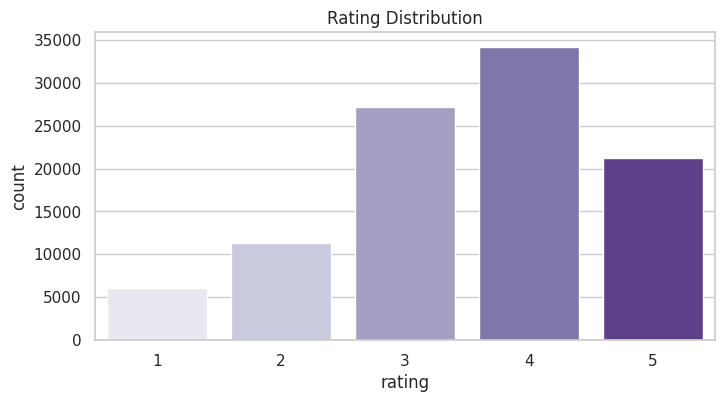

In [4]:
rating_summary = ratings["rating"].describe()
display(rating_summary)

fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=ratings, x="rating", ax=ax, palette="Purples")
ax.set_title("Rating Distribution")
plt.show()

## 3. 유저당 / 아이템당 평점 수 분포

In [5]:
user_counts, item_counts = interaction_counts(ratings)
display(user_counts.describe().rename("user_rating_count"))
display(item_counts.describe().rename("item_rating_count"))

count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
Name: user_rating_count, dtype: float64

count    1682.000000
mean       59.453032
std        80.383846
min         1.000000
25%         6.000000
50%        27.000000
75%        80.000000
max       583.000000
Name: item_rating_count, dtype: float64

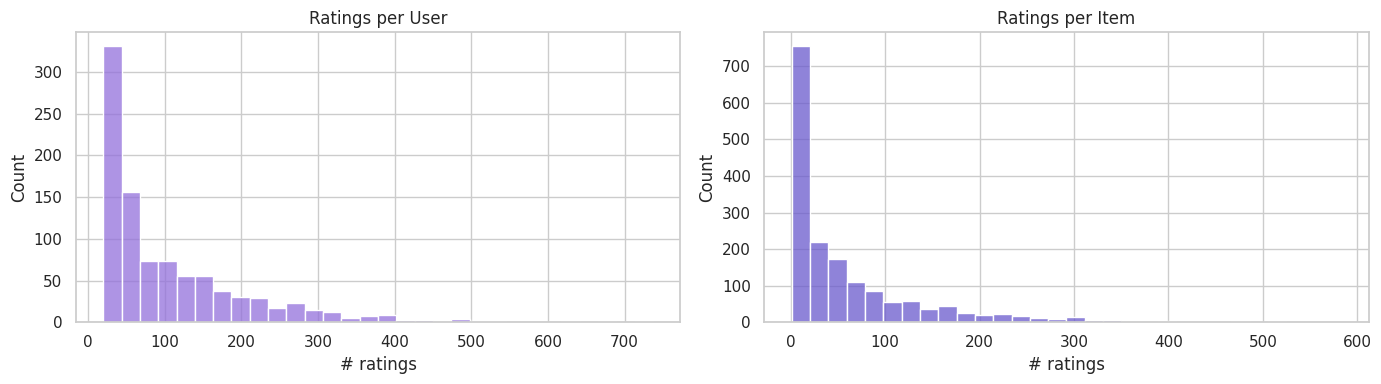

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(user_counts, bins=30, ax=axes[0], color="mediumpurple")
axes[0].set_title("Ratings per User")
axes[0].set_xlabel("# ratings")

sns.histplot(item_counts, bins=30, ax=axes[1], color="slateblue")
axes[1].set_title("Ratings per Item")
axes[1].set_xlabel("# ratings")

plt.tight_layout()
plt.show()

## 4. 희소성(Sparsity)

In [7]:
sparsity = calculate_sparsity(ratings)
print(f"Sparsity: {sparsity:.4%}")

Sparsity: 93.6953%


## 5. 시간에 따른 평점 트렌드

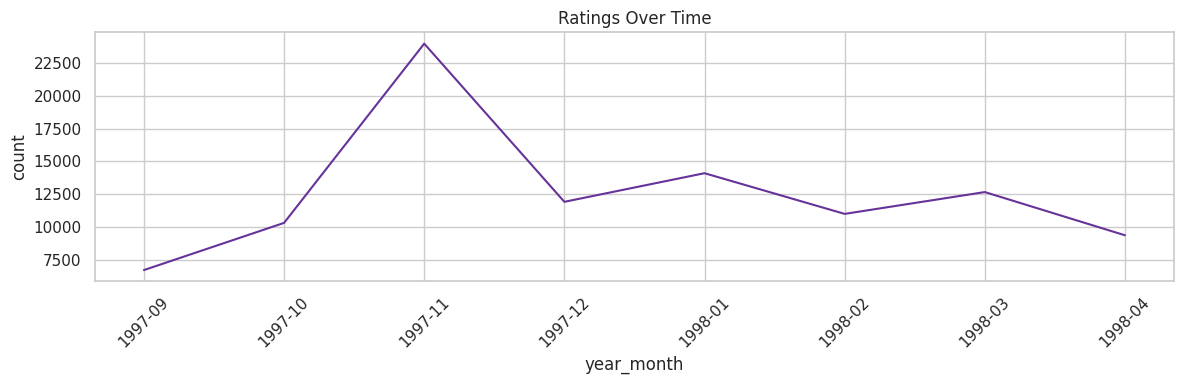

In [8]:
ratings_by_month = (
    ratings.assign(year_month=ratings["rated_at"].dt.to_period("M").astype(str))
    .groupby("year_month")
    .size()
    .rename("rating_count")
)

fig, ax = plt.subplots(figsize=(12, 4))
ratings_by_month.plot(ax=ax, color="rebeccapurple")
ax.set_title("Ratings Over Time")
ax.set_ylabel("count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Explicit / Implicit 피드백 구성

In [9]:
explicit_matrix = create_user_item_matrix(ratings, value_column="rating", fill_value=0.0)
implicit_feedback = create_implicit_feedback(ratings, threshold=HIGH_RATING_THRESHOLD)
implicit_matrix = create_user_item_matrix(
    implicit_feedback.rename(columns={"interaction": "implicit_signal"}),
    value_column="implicit_signal",
    fill_value=0.0,
)

print("Explicit matrix shape:", explicit_matrix.shape)
print("Implicit matrix shape:", implicit_matrix.shape)
implicit_feedback.head()

Explicit matrix shape: (943, 1682)
Implicit matrix shape: (943, 1682)


,user_id,item_id,timestamp,rated_at,interaction
0,259,255,874724710,1997-09-20 03:05:10,1
1,259,286,874724727,1997-09-20 03:05:27,1
2,259,298,874724754,1997-09-20 03:05:54,1
3,259,185,874724781,1997-09-20 03:06:21,1
4,259,173,874724843,1997-09-20 03:07:23,1


## 7. Cold-start 유저 / 아이템 식별

In [10]:
cold_start = identify_cold_start_entities(ratings)
print("Cold-start users:", len(cold_start["cold_start_users"]))
print("Cold-start items:", len(cold_start["cold_start_items"]))

Cold-start users: 0
Cold-start items: 333


## 8. Train / Test 분할 전략 비교

In [11]:
train_random, test_random = random_train_test_split(ratings, test_size=0.2)
train_time, test_time = time_based_train_test_split(ratings, test_ratio=0.2)

split_summary = pd.DataFrame({
    "split": ["random_train", "random_test", "time_train", "time_test"],
    "rows": [len(train_random), len(test_random), len(train_time), len(test_time)],
    "min_timestamp": [
        train_random["rated_at"].min(),
        test_random["rated_at"].min(),
        train_time["rated_at"].min(),
        test_time["rated_at"].min(),
    ],
    "max_timestamp": [
        train_random["rated_at"].max(),
        test_random["rated_at"].max(),
        train_time["rated_at"].max(),
        test_time["rated_at"].max(),
    ],
})
split_summary

,split,rows,min_timestamp,max_timestamp
0,random_train,80000,1997-09-20 03:05:10,1998-04-22 23:10:38
1,random_test,20000,1997-09-20 03:08:57,1998-04-22 23:10:38
2,time_train,80000,1997-09-20 03:05:10,1998-03-07 02:21:09
3,time_test,20000,1998-03-07 02:21:09,1998-04-22 23:10:38


## 9. 베이스라인 준비

In [12]:
baseline_info = baseline_summary(train_random)
popular_items = popularity_scores(train_random).head(10)
display(pd.Series(baseline_info))
display(popular_items)

global_mean_rating                   3.529587
n_users                            943.000000
n_items                           1652.000000
most_popular_item_id                50.000000
most_popular_item_interactions     463.000000
dtype: float64

,item_id,interaction_count,mean_rating
0,50,463,4.358531
1,100,407,4.164619
2,181,395,4.045570
3,258,391,3.800512
4,288,389,3.457584
5,294,380,3.123684
6,286,376,3.646277
7,1,362,3.875691
8,121,350,3.468571
9,127,348,4.298851


## 10. 평가 프레임워크 메모
- 후보 K: `(5, 10, 20)`
- 대표 기본값: `10`
- 최소 추적 지표: RMSE, Precision@K, Recall@K, NDCG@K, MAP
- 추가 지표: Coverage, Intra-list Diversity
- 베이스라인: 전체 평균, 유저 평균, 인기도 기반
- 중요: Top-K 추천 평가는 학습에서 이미 본 아이템을 제외하고 계산

## 다음 단계
1. EDA 결과를 기반으로 베이스라인 추천기를 정의한다.
2. Day 2에서 User-CF / Item-CF / SVD / ALS를 비교한다.
3. 평가 지표 계산은 `src/evaluation/` 유틸을 재사용한다.